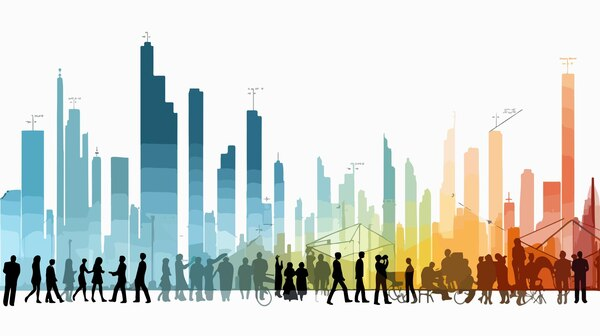

<span style="color:green; font-size:24px; font-weight:bold;">
PROYECTO EDA: 
</span>



<span style="color:green; font-size:30px; font-weight:bold;">
LA DEMOGRAFÍA DE EUSKADI: ANÁLISIS DE PARÁMETROS BÁSICOS y EVOLUCIÓN RECIENTE
</span>

El estudio planteado tiene como <u>principal objetivo</u> llevar a cabo una aproximación a la evolución reciente de la estructura poblacional del País Vasco.

En las últimas décadas se han producido importantes cambios en la estructura, composición y dinámicas poblacionales de Euskadi. El objetivo es recoger algunos datos relevantes relacionados con algunos de los principales parámetros que explican la dinámica demográfica de la sociedad vasca, destacando los cambios más importantes y aquellos fenómenos que pueden venir a explicar tales cambios.

Algunos de los <u>aspectos a analizar</u>:

- Tamaño poblacional. Número de residentes en Euskadi y evolución en las últimas décadas.
- Movimiento natural de la población: evolución en número de nacimientos y defunciones en las últimas décadas, prestando especial atención a las dinámicas relacionadas con la natalidad (nacimientos, fecundidad).
- Movimientos migratorios. Valoración del impacto que la entrada de población extranjera está teniendo en la estructura de población de Euskadi, prestando especial atención a las diferencias en el comportamiento en relación con la natalidad.
- Previsible evolución de la natalidad en los próximos años, atendiendo a la actual estructura poblacional.

Principales <u>fuentes de información</u> utilizadas: 

INE (Instituto Nacional de Estadística):
- Estadística Continua de Población (población a 1 de enero de cada año)
- Estadística de Nacimientos
- Indicadores de Natalidad
- Indicadores de Fecundidad
- Estadística de Defunciones

EUSTAT (Instituto Vasco de Estadística):
- Microdatos de la Estadística de Nacimientos
- Estadística de movimientos migratorios




<span style="color:green; font-size:24px; font-weight:bold;">
BASES DE DATOS A UTILIZAR: 
</span>

In [11]:
import numpy as np
import pandas as pd


<span style="color:green; font-size:16px; font-weight:bold;">
BASE DE DATOS DE ELABORACIÓN PROPIA A PARTIR DE DESCARGA DE DATOS PROCEDENTES DEL INE Y EL EUSTAT:
</span>

In [12]:
ine = pd.read_csv(r"./ine_original_2.csv", sep=",", decimal=",", encoding="latin1")
ine

,,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Total_Nacimientos,39646.0,41100.0,38806.0,35657.0,31835.0,28812.0,27255.0,25670.0,23920.0,...,18247.0,17077.0,16100.0,15449.0,14743.0,14276.0,13663.0,13462.0,12950.0,NaN
1,Nac_Esp_Todaslasedades,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15156.0,14102.0,12920.0,12127.0,11452.0,11215.0,10510.0,10061.0,9511.0,NaN
2,Nac_Esp_Menosde15anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,2.0,2.0,2.0,3.0,1.0,NaN,NaN
3,Nac_Esp_15a19anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,140.0,124.0,89.0,107.0,99.0,99.0,100.0,102.0,63.0,NaN
4,Nac_Esp_20a24anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,411.0,369.0,359.0,376.0,339.0,305.0,335.0,324.0,333.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,Pob_Ext_Mujeres_70a74anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,970.0,1053.0,1187.0,1329.0,1524.0,1697.0,1927.0,2223.0,2518.0,2962.0
409,Pob_Ext_Mujeres_75a79anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,803.0,825.0,816.0,854.0,875.0,956.0,1041.0,1218.0,1421.0,1626.0
410,Pob_Ext_Mujeres_80a84anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,431.0,421.0,512.0,558.0,636.0,683.0,714.0,739.0,804.0,880.0
411,Pob_Ext_Mujeres_85a89anios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,363.0,401.0,375.0,348.0,343.0,330.0,339.0,417.0,478.0,531.0


<span style="color:green; font-size:16px; font-weight:bold;">
FICHEROS DE MICRODATOS (ESTADISTICA DE NACIMIENTOS DEL EUSTAT):
</span>

In [32]:
eustat = pd.read_csv(r"./fichero_final_nac_2024.csv", sep=",", encoding="latin1")
eustat

,CODMUN_INS,PAE_DIAI,PAE_MESI,PAE_ANOI,PAE_DIAN,PAE_MESN,PAE_ANON,PAE_LNAC,PAE_ASSN,PAE_MULT,...,ORDNA,PAE_EDADM1,PAE_EDAMA2,PAE_EDAMA4,PAE_PROMA1,PAE_DURMAT,PAE_EDAPA2,PAE_EDAPA4,PAE_PROPA1,PAE_PESO
0,20999,17.0,10.0,2024.0,14,10,2024,2,1,1,...,1.0,NaN,37,2,2,NaN,NaN,1,NaN,3040
1,20055,22.0,7.0,2024.0,18,7,2024,2,1,1,...,1.0,NaN,43,2,3,NaN,NaN,1,NaN,3470
2,48020,19.0,6.0,2024.0,14,6,2024,2,1,1,...,2.0,NaN,30,1,3,NaN,NaN,1,NaN,3460
3,20045,30.0,1.0,2024.0,26,1,2024,2,1,1,...,1.0,NaN,20,1,2,NaN,NaN,1,NaN,2580
4,1059,3.0,12.0,2024.0,28,11,2024,2,1,1,...,1.0,NaN,15,2,4,NaN,NaN,1,NaN,2600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12982,48020,30.0,5.0,2024.0,27,5,2024,2,1,1,...,2.0,NaN,21,2,5,NaN,21.0,1,4.0,3200
12983,48020,12.0,4.0,2024.0,9,4,2024,2,1,1,...,1.0,29.0,34,2,2,5.0,33.0,2,4.0,2670
12984,20069,23.0,8.0,2024.0,2,8,2024,2,1,1,...,2.0,38.0,38,1,3,0.0,33.0,2,3.0,3600
12985,48020,26.0,12.0,2024.0,16,12,2024,2,1,1,...,1.0,NaN,38,2,1,NaN,36.0,1,4.0,3200


<span style="color:green; font-size:24px; font-weight:bold;">
HIPÓTESIS: 
</span>


Las <u>hipótesis preliminares</u> a contrastar a través del análisis de los datos planteados son las siguientes:
1. La población de Euskadi está en un claro proceso de envejecimiento.

2. Pese a estar experimentando un proceso de envejecimiento, la población de Euskadi crece en los últimos años, si bien este crecimiento se explica por la entrada de población (proceso inmigratorio), no así por crecimiento natural de la población (natalidad).

3. La entrada de población de origen extranjero está impactando de diversas maneras en la estructura poblacional, entre ellas contribuyendo al rejuvenecimiento de la misma,  
3.1. por la incorporación de población joven que modifica la pirámide poblacional,  
3.2. y por la introducción de pautas de natalidad diferentes a las de la población local.

4. Tras más de una década de caída en la natalidad, en los próximos años es previsible se produzca un ligero incremento de la misma,  si bien este incremento será moderado y breve en el tiempo.

In [13]:
ine.info()

<class 'pandas.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 52 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0           413 non-null    str    
 1   1975    268 non-null    float64
 2   1976    268 non-null    float64
 3   1977    268 non-null    float64
 4   1978    268 non-null    float64
 5   1979    268 non-null    float64
 6   1980    268 non-null    float64
 7   1981    268 non-null    float64
 8   1982    268 non-null    float64
 9   1983    268 non-null    float64
 10  1984    268 non-null    float64
 11  1985    268 non-null    float64
 12  1986    268 non-null    float64
 13  1987    268 non-null    float64
 14  1988    268 non-null    float64
 15  1989    268 non-null    float64
 16  1990    268 non-null    float64
 17  1991    269 non-null    float64
 18  1992    269 non-null    float64
 19  1993    269 non-null    float64
 20  1994    269 non-null    float64
 21  1995    269 non-null    float64
 22  1996    269 n

In [14]:
ine.describe(include="all")

,,1975,1976,1977,1978,1979,1980,1981,1982,1983,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,413,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,2.680000e+02,...,4.090000e+02,4.110000e+02,4.110000e+02,4.080000e+02,4.090000e+02,4.090000e+02,4.100000e+02,4.090000e+02,4.100000e+02,3.220000e+02
unique,413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Total_Nacimientos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.999397e+04,3.044144e+04,3.087619e+04,3.126304e+04,3.159576e+04,3.187998e+04,3.213454e+04,3.221977e+04,3.224681e+04,...,2.334200e+04,2.334823e+04,2.353069e+04,2.396582e+04,2.421454e+04,2.432818e+04,2.429381e+04,2.469280e+04,2.494648e+04,3.183973e+04
std,NaN,1.471910e+05,1.493505e+05,1.515852e+05,1.536135e+05,1.553979e+05,1.569121e+05,1.582250e+05,1.586997e+05,1.588929e+05,...,1.311194e+05,1.311783e+05,1.316695e+05,1.328183e+05,1.336530e+05,1.337638e+05,1.332339e+05,1.341625e+05,1.348234e+05,1.527030e+05
min,NaN,2.780000e+00,2.840000e+00,2.650000e+00,2.390000e+00,2.090000e+00,1.860000e+00,1.730000e+00,1.620000e+00,1.500000e+00,...,-2.977000e+03,-4.557000e+03,-5.663000e+03,-6.117000e+03,-9.509000e+03,-8.810000e+03,-1.054000e+04,-8.866000e+03,-9.447000e+03,4.630000e+01
25%,NaN,8.015500e+03,8.241750e+03,8.306250e+03,8.435750e+03,8.770500e+03,9.576750e+03,1.005575e+04,1.002250e+04,1.011050e+04,...,3.570000e+03,3.219000e+03,3.559000e+03,4.078500e+03,4.199000e+03,3.889000e+03,3.874500e+03,4.321000e+03,4.353250e+03,1.099450e+04
50%,NaN,1.449550e+04,1.457350e+04,1.471500e+04,1.482950e+04,1.487550e+04,1.504400e+04,1.514700e+04,1.508650e+04,1.507400e+04,...,1.069600e+04,1.077300e+04,1.089900e+04,1.105450e+04,1.125200e+04,1.127700e+04,1.126550e+04,1.141000e+04,1.168950e+04,1.422500e+04
75%,NaN,1.931250e+04,1.957700e+04,1.986500e+04,1.984075e+04,1.973250e+04,1.962600e+04,1.955575e+04,1.956200e+04,1.949525e+04,...,1.759200e+04,1.754550e+04,1.761150e+04,1.781850e+04,1.782600e+04,1.792100e+04,1.788525e+04,1.799300e+04,1.827450e+04,2.185050e+04
